# 03 — Predictive Model

Quantile regression to predict future VM CPU utilization with uncertainty.
Uses 25 days for training, last 6 days for validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import QuantileRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import joblib
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
DATA = Path("../data/processed")

## 1. Load daily CPU time series

In [2]:
daily = pd.read_csv(DATA / "vm_cpu_daily.csv")
print(f"VMs: {len(daily):,}")
print(f"Days: {daily.columns[1:].tolist()[:5]} ... {daily.columns[-3:].tolist()}")

dates = daily.columns[1:].tolist()
n_days = len(dates)
print(f"Total days: {n_days}")

VMs: 123,357
Days: ['2024-08-01', '2024-08-02', '2024-08-03', '2024-08-04', '2024-08-05'] ... ['2024-08-29', '2024-08-30', '2024-08-31']
Total days: 31


## 2. Feature engineering

For each VM, compute rolling features from the training window (first 25 days):
- Mean, std, min, max, p5, p25, p50, p75, p95
- Trend (slope of linear fit)
- Coefficient of variation

In [3]:
TRAIN_DAYS = 25
train_dates = dates[:TRAIN_DAYS]
test_dates = dates[TRAIN_DAYS:]
print(f"Train: {train_dates[0]} to {train_dates[-1]} ({len(train_dates)} days)")
print(f"Test:  {test_dates[0]} to {test_dates[-1]} ({len(test_dates)} days)")

Train: 2024-08-01 to 2024-08-25 (25 days)
Test:  2024-08-26 to 2024-08-31 (6 days)


In [4]:
train_vals = daily[train_dates].values.astype(float)
test_vals = daily[test_dates].values.astype(float)

valid_mask = ~np.isnan(train_vals).all(axis=1) & ~np.isnan(test_vals).all(axis=1)
print(f"VMs with data in both windows: {valid_mask.sum():,}")

train_vals = train_vals[valid_mask]
test_vals = test_vals[valid_mask]
instances = daily.loc[valid_mask, "instance"].values

VMs with data in both windows: 47,053


In [5]:
def build_features(matrix):
    n = matrix.shape[0]
    feats = np.zeros((n, 11))
    for i in range(n):
        row = matrix[i]
        row = row[~np.isnan(row)]
        if len(row) == 0:
            continue
        feats[i, 0] = np.mean(row)
        feats[i, 1] = np.std(row)
        feats[i, 2] = np.min(row)
        feats[i, 3] = np.max(row)
        feats[i, 4] = np.percentile(row, 5)
        feats[i, 5] = np.percentile(row, 25)
        feats[i, 6] = np.percentile(row, 50)
        feats[i, 7] = np.percentile(row, 75)
        feats[i, 8] = np.percentile(row, 95)
        if len(row) > 1:
            feats[i, 9] = np.polyfit(range(len(row)), row, 1)[0]  # trend
        feats[i, 10] = feats[i, 1] / feats[i, 0] if feats[i, 0] > 0 else 0  # CV
    return feats

feature_names = ["mean", "std", "min", "max", "p5", "p25", "p50", "p75", "p95", "trend", "cv"]
X = build_features(train_vals)
y_mean = np.nanmean(test_vals, axis=1)

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y_mean.shape}")
print(f"Target stats — mean: {np.mean(y_mean):.2f}, median: {np.median(y_mean):.2f}")

Features shape: (47053, 11)
Target shape:   (47053,)
Target stats — mean: 8.03, median: 5.91


## 3. Train quantile regression models

We train three models: q=0.10 (optimistic), q=0.50 (median), q=0.90 (pessimistic).
This gives us the prediction interval: "this VM will use between X% and Y% CPU next month."

In [6]:
quantiles = [0.10, 0.50, 0.90]
models = {}

for q in quantiles:
    print(f"Training q={q}...")
    model = GradientBoostingRegressor(
        loss="quantile", alpha=q,
        n_estimators=200, max_depth=4, learning_rate=0.1,
        random_state=42
    )
    model.fit(X, y_mean)
    pred = model.predict(X)
    mae = mean_absolute_error(y_mean, pred)
    print(f"  MAE: {mae:.2f}%")
    models[q] = model

Training q=0.1...


  MAE: 2.99%
Training q=0.5...


  MAE: 1.30%
Training q=0.9...


  MAE: 2.04%


## 4. Evaluate predictions

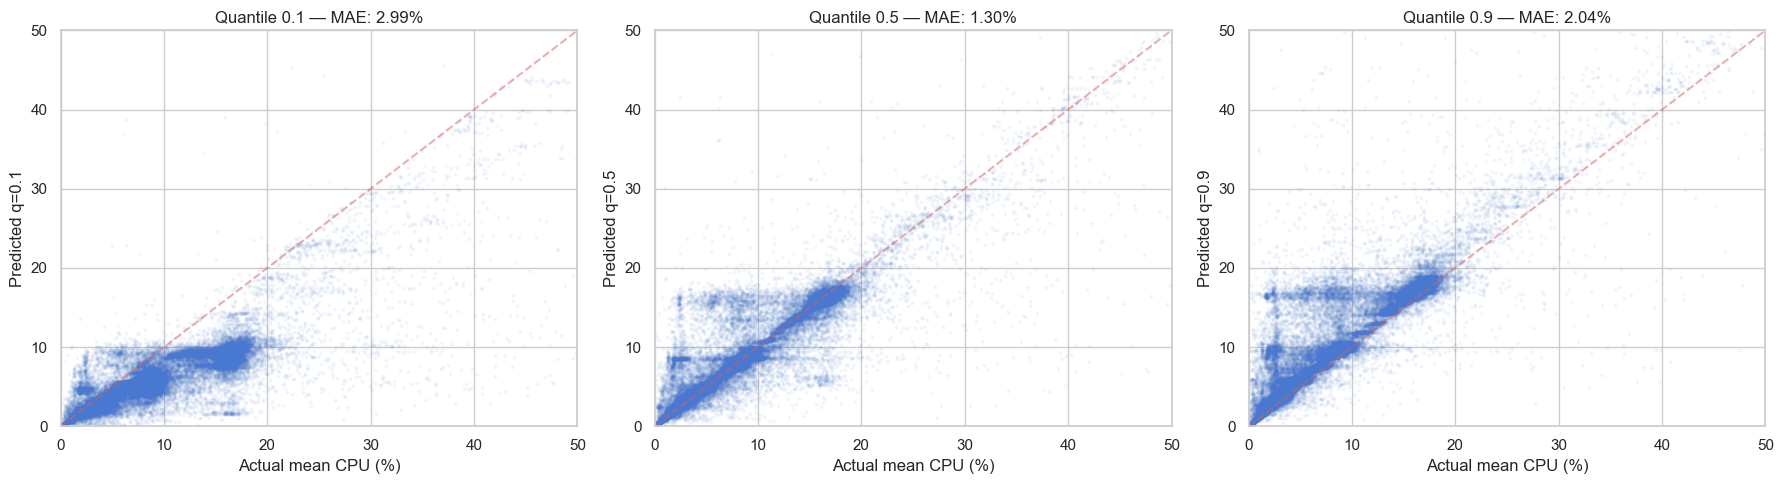

In [7]:
preds = {q: models[q].predict(X) for q in quantiles}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, q in zip(axes, quantiles):
    ax.scatter(y_mean, preds[q], alpha=0.05, s=3)
    ax.plot([0, 100], [0, 100], "r--", alpha=0.5)
    ax.set_xlabel("Actual mean CPU (%)")
    ax.set_ylabel(f"Predicted q={q}")
    ax.set_title(f"Quantile {q} — MAE: {mean_absolute_error(y_mean, preds[q]):.2f}%")
    ax.set_xlim(0, 50)
    ax.set_ylim(0, 50)

plt.tight_layout()
plt.savefig("../reports/figures/model_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
coverage = np.mean((y_mean >= preds[0.10]) & (y_mean <= preds[0.90]))
print(f"80% prediction interval coverage: {coverage*100:.1f}%")

80% prediction interval coverage: 80.1%


## 5. Feature importance

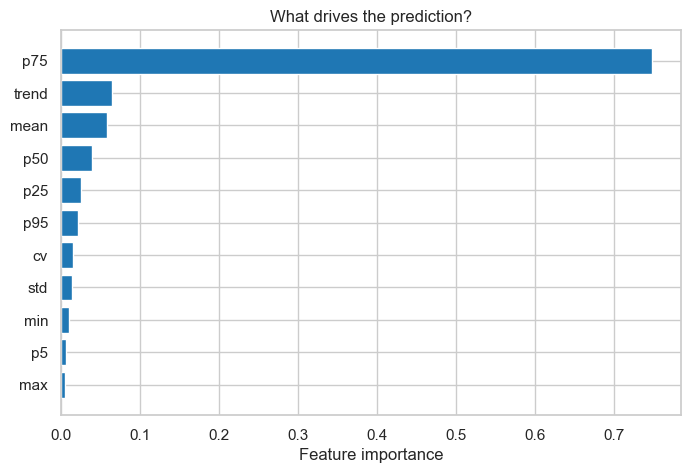

In [9]:
importances = models[0.50].feature_importances_
feat_imp = pd.DataFrame({"feature": feature_names, "importance": importances})
feat_imp = feat_imp.sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_imp["feature"], feat_imp["importance"], color="#1f77b4", edgecolor="white")
ax.set_xlabel("Feature importance")
ax.set_title("What drives the prediction?")
ax.invert_yaxis()
plt.savefig("../reports/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Savings recommendations with confidence

For each VM, use the prediction interval to recommend an action with risk.

In [10]:
PRICE_PER_CPU_PCT_HOUR = 0.001  # simplified: $0.001 per 1% CPU per hour
HOURS_MONTH = 730

recs = pd.DataFrame({
    "instance": instances,
    "actual_cpu": y_mean,
    "pred_low": preds[0.10],
    "pred_mid": preds[0.50],
    "pred_high": preds[0.90],
})

def recommend(row):
    if row["pred_high"] < 5:
        return "terminate"
    if row["pred_high"] < 20:
        return "downsize"
    if row["pred_mid"] < 50:
        return "review"
    return "keep"

recs["action"] = recs.apply(recommend, axis=1)
recs["monthly_savings"] = (recs["actual_cpu"] - recs["pred_mid"]).clip(lower=0) * PRICE_PER_CPU_PCT_HOUR * HOURS_MONTH

action_counts = recs["action"].value_counts()
print("Recommended actions:")
for action in ["terminate", "downsize", "review", "keep"]:
    n = action_counts.get(action, 0)
    savings = recs.loc[recs["action"] == action, "monthly_savings"].sum()
    print(f"  {action:>10}: {n:>7,} VMs — ${savings:>10,.0f}/month savings potential")

Recommended actions:
   terminate:  17,090 VMs — $     1,726/month savings potential
    downsize:  27,599 VMs — $    14,052/month savings potential
      review:   2,215 VMs — $     4,061/month savings potential
        keep:     149 VMs — $       383/month savings potential


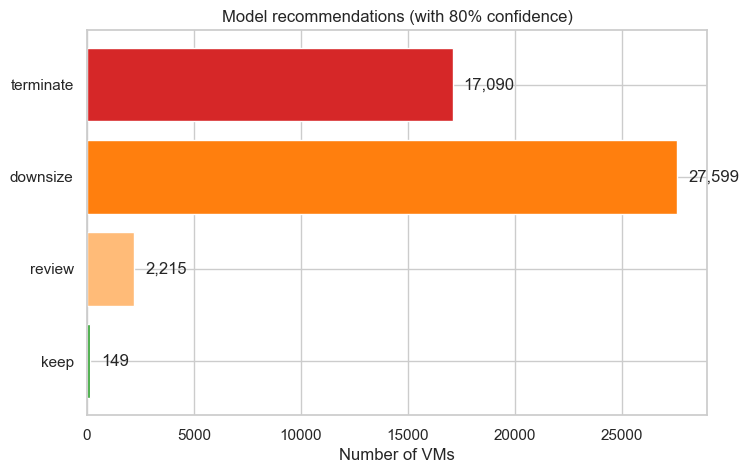

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"terminate": "#d62728", "downsize": "#ff7f0e", "review": "#ffbb78", "keep": "#2ca02c"}
order = ["terminate", "downsize", "review", "keep"]
bars = [action_counts.get(c, 0) for c in order]
bar_colors = [colors[c] for c in order]

ax.barh(order, bars, color=bar_colors, edgecolor="white")
for i, v in enumerate(bars):
    ax.text(v + 500, i, f"{v:,}", va="center")
ax.set_xlabel("Number of VMs")
ax.set_title("Model recommendations (with 80% confidence)")
ax.invert_yaxis()
plt.savefig("../reports/figures/recommendations.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Save model

In [12]:
for q, model in models.items():
    joblib.dump(model, f"../models/quantile_{q:.2f}.joblib")
    print(f"Saved models/quantile_{q:.2f}.joblib")

recs.to_csv(DATA / "vm_recommendations.csv", index=False)
print(f"Saved {len(recs)} recommendations to data/processed/vm_recommendations.csv")

Saved models/quantile_0.10.joblib
Saved models/quantile_0.50.joblib
Saved models/quantile_0.90.joblib


Saved 47053 recommendations to data/processed/vm_recommendations.csv
